In [ ]:
import random
from importlib import reload

import common

reload(common)
from common import priority_topological_sort


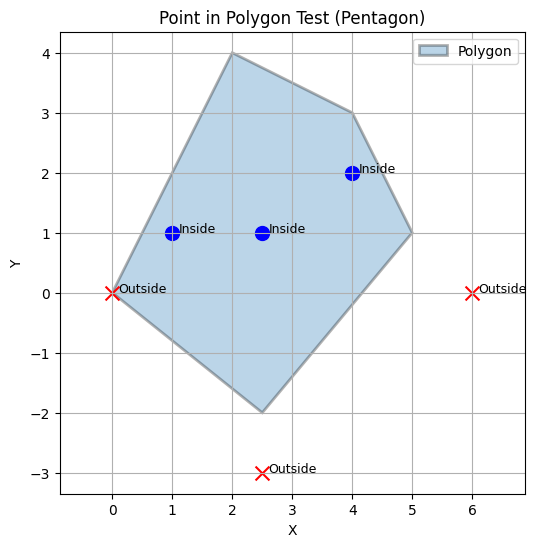

In [7]:
import matplotlib.pyplot as plt


def is_point_in_polygon(polygon: list[tuple[float, float]], x: float, y: float) -> bool:
    inside = False
    n = len(polygon)
    px, py = x, y

    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]

        if min(y1, y2) < py <= max(y1, y2):
            x_intersect = (py - y1) * (x2 - x1) / (y2 - y1 + 1e-10) + x1
            if px < x_intersect:
                inside = not inside

    return inside


# --- 五角形の定義 ---
pentagon = [(0, 0), (2, 4), (4, 3), (5, 1), (2.5, -2)]

# --- テスト点 ---
test_points = [
    (2.5, 1),  # 内部
    (1, 1),  # 内部
    (4, 2),  # 内部
    (0, 0),  # 境界（頂点）
    (6, 0),  # 外部
    (2.5, -3),  # 外部
]

# --- 可視化 ---
plt.figure(figsize=(6, 6))

# ポリゴン描画
polygon_x, polygon_y = zip(*pentagon)
plt.fill(
    polygon_x + (polygon_x[0],), polygon_y + (polygon_y[0],), alpha=0.3, edgecolor="black", linewidth=2, label="Polygon"
)

# 点の描画
for x, y in test_points:
    inside = is_point_in_polygon(x, y, pentagon)
    color = "blue" if inside else "red"
    marker = "o" if inside else "x"
    label = "Inside" if inside else "Outside"
    plt.scatter(x, y, color=color, marker=marker, s=100)
    plt.text(x + 0.1, y, f"{label}", fontsize=9)

plt.title("Point in Polygon Test (Pentagon)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


In [9]:
import itertools
import math
import random
from collections import namedtuple

# --- 点の定義 ---
Point = namedtuple("Point", ["x", "y"])

# --- ランダムな800点を生成 ---
random.seed(42)
points = [Point(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(800)]


# --- 距離計算 ---
def distance(p1, p2):
    return math.hypot(p1.x - p2.x, p1.y - p2.y)


# --- 三角形が正三角形にどれだけ近いか（辺の長さの標準偏差で評価） ---
def triangle_score(p1, p2, p3):
    d1 = distance(p1, p2)
    d2 = distance(p2, p3)
    d3 = distance(p3, p1)
    mean = (d1 + d2 + d3) / 3
    variance = ((d1 - mean) ** 2 + (d2 - mean) ** 2 + (d3 - mean) ** 2) / 3
    return math.sqrt(variance)


# --- 近傍点を使って候補三角形を評価 ---
best_score = float("inf")
best_triangle = None

# 探索範囲：各点に対して近い点 上位K個のみ考慮（高速化）
K = 10
for i, p in enumerate(points):
    # 各点との距離を計算し、近い順にソート
    dists = sorted(((distance(p, q), q) for j, q in enumerate(points) if i != j), key=lambda x: x[0])
    neighbors = [q for _, q in dists[:K]]

    # 近傍点から2点を選んで三角形を構成
    for q1, q2 in itertools.combinations(neighbors, 2):
        score = triangle_score(p, q1, q2)
        if score < best_score:
            best_score = score
            best_triangle = (p, q1, q2)

print("最も正三角形に近かった点:")
for p in best_triangle:
    print(f"({p.x:.2f}, {p.y:.2f})")
print(f"スコア（辺長のばらつき）: {best_score:.6f}")

最も正三角形に近かった点:
(87.59, 26.34)
(88.16, 24.39)
(86.17, 24.87)
スコア（辺長のばらつき）: 0.006674


In [ ]:
def sorted_dag(
    vs: list[int],  # 頂点のリスト
    graph: dict[int, list[int]],  # 隣接リスト
    graph_r: dict[int, list[int]],  # 逆グラフ
    initial_ranking: list[int],  # 初期のランク
):
    """閉路を含むDAGを初期のランクに従ってソートする"""
    label_num, group = scc(graph, graph_r, vs)
    ssc_graph, belong_lists = scc_construct(graph, label_num, group, vs)

    num_to_ranking = {i: j for j, i in enumerate(initial_ranking)}
    construct_initial_ranking = {}
    for i, belong_list in enumerate(belong_lists):
        ssc_ranks = [num_to_ranking[v] for v in belong_list]
        n = len(ssc_ranks)
        mid_rank = sorted(ssc_ranks)[n // 2]
        construct_initial_ranking[i] = mid_rank

    result_rank_construct = priority_topological_sort(ssc_graph, construct_initial_ranking)
    result_rank = []
    for i in result_rank_construct:
        now_belong = belong_lists[i]
        result_rank.extend(now_belong)

    return result_rank

In [ ]:
random.seed(1)
constraints = []

for _ in range(16):
    v1 = random.randint(50, 60)
    v2 = random.randint(50, 60)
    if v1 == v2:
        continue
    constraints.append((v1, v2))

vs = set()
for u, v in constraints:
    vs.add(u)
    vs.add(v)
vs = list(vs)

initial_ranking = sorted(vs, key=lambda x: random.random())
scc_graph, graph_r = construct_dag_from_edges(constraints, vs)

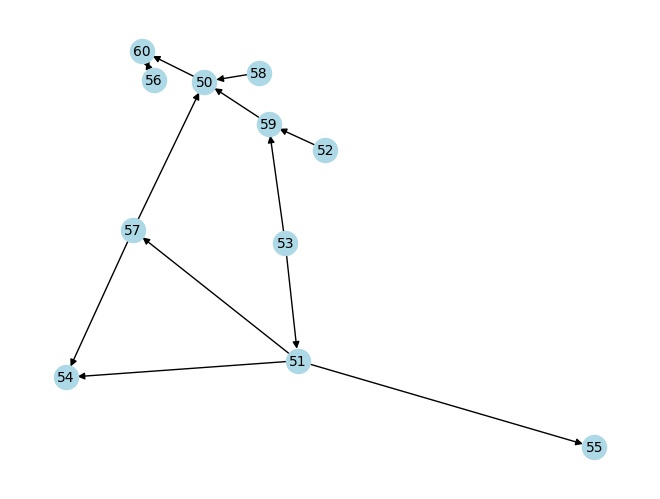

In [313]:
import networkx as nx

nx_graph = nx.DiGraph(constraints)

nx.draw(nx_graph, nx.spring_layout(nx_graph), with_labels=True, node_color="lightblue", node_size=300, font_size=10)